# Baseline model: TF-IDF + Logistic Regression

**Project:** Secure Local Mail System with ML-Based Spam Detection  
**Author:** Abdulla AlBassam  
**Module:** KV6013, Individual Computing Project  

Trains the baseline classifier (TF-IDF features into Logistic Regression) and saves both the trained model and the fitted vectoriser. This is the reference point that the fine-tuned DistilBERT model in notebook 03 has to beat, and the model the adversarial attacks in Phase 6 will measure degradation against.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score,
    precision_score, recall_score, f1_score
)

from preprocessing import load_enron_data, preprocess_dataset

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 150

print('Libraries loaded.')

Libraries loaded successfully.


## 1. Load and preprocess data

In [2]:
df_raw = load_enron_data('../data/raw/enron_spam_data.csv')
print(f'Raw dataset: {len(df_raw):,} rows')

df = preprocess_dataset(df_raw)
print(f'After preprocessing: {len(df):,} rows')
print(f'Rows removed: {len(df_raw) - len(df)}')
print(f'\nLabel distribution:')
print(f'  Ham (0):  {(df["label"] == 0).sum():,} ({(df["label"] == 0).mean() * 100:.1f}%)')
print(f'  Spam (1): {(df["label"] == 1).sum():,} ({(df["label"] == 1).mean() * 100:.1f}%)')

Raw dataset: 33,716 rows


After preprocessing: 33,662 rows
Rows removed: 54

Label distribution:
  Ham (0):  16,545 (49.2%)
  Spam (1): 17,117 (50.8%)


## 2. Train/test split

80/20 split, stratified by label so the class ratio is preserved in both halves. The test set is held back until the final evaluation; nothing about model selection or hyperparameter tuning is allowed to peek at it. This is the standard discipline for honest test-set numbers and matters here because the cross-validation step below uses only the training set.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    df['text'], df['label'],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

print(f'Training set: {len(X_train):,} samples')
print(f'Test set:     {len(X_test):,} samples')
print(f'\nTraining label distribution: {dict(y_train.value_counts())}')
print(f'Test label distribution:     {dict(y_test.value_counts())}')

Training set: 26,929 samples
Test set:     6,733 samples

Training label distribution: {1: 13693, 0: 13236}
Test label distribution:     {1: 3424, 0: 3309}


## 3. TF-IDF feature extraction

Why each of these knobs was set the way it is:

- `max_features=10000` caps the vocabulary so the model doesn't try to learn a coefficient for every long-tail token. Rare-term overfitting is the easiest way to get a too-optimistic CV score on this corpus.
- `ngram_range=(1, 2)` keeps unigrams and bigrams. Bigrams matter here because phrases like "click here" and "free offer" carry more spam signal than either word in isolation.
- `sublinear_tf=True` applies `1 + log(tf)` so a word repeated 50 times in one email doesn't dominate a word that appears once. Spam often relies on repetition, and without sublinear scaling the loudest emails would skew everything.
- `min_df=2` drops terms that appear in only a single document. Those are almost always typos, random tokens, or one-off noise.
- `max_df=0.95` drops terms appearing in more than 95% of documents. Implicit stopword removal for anything sklearn's list misses.
- `stop_words='english'` strips the standard English stopwords so the model isn't fighting "the", "and", "to" for coefficient mass.

In [4]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2,
    max_df=0.95,
    stop_words='english'
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f'Vocabulary size: {len(tfidf.vocabulary_):,}')
print(f'Training matrix shape: {X_train_tfidf.shape}')
print(f'Test matrix shape:     {X_test_tfidf.shape}')
print(f'Sparsity: {1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1]):.4%}')

Vocabulary size: 10,000
Training matrix shape: (26929, 10000)
Test matrix shape:     (6733, 10000)
Sparsity: 99.2301%


## 4. Logistic Regression training

- `C=1.0` is sklearn's default regularisation strength. With 10K features, L2 regularisation is doing real work; loosening C made the CV variance worse in early experiments.
- `solver='lbfgs'` is the right fit for this dataset size with L2: fast and well-behaved. liblinear would also work but doesn't parallelise as nicely.
- `max_iter=1000` is bumped from sklearn's default of 100. With 10K-dimensional sparse features the optimiser sometimes needs more steps to converge cleanly, and a "did not converge" warning would invalidate the CV numbers.

In [5]:
lr_model = LogisticRegression(
    C=1.0,
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)
print('Model trained successfully.')
print(f'Number of iterations: {lr_model.n_iter_[0]}')

Model trained successfully.
Number of iterations: 14


## 5. Cross-validation

5-fold stratified CV on the training set, never on the test set. Two things this is checking: (1) is the model stable across folds, and (2) is there a worrying gap between train and validation scores that would suggest overfitting? If the gap is small and the variance is small, I'm confident the test-set evaluation is meaningful rather than a fluke.

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, random_state=42),
    X_train_tfidf, y_train,
    cv=cv,
    scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
    return_train_score=True
)

print('5-Fold Cross-Validation Results (on training set):')
print('=' * 70)
print(f'{"Metric":>12}  {"Train Mean":>12}  {"Train Std":>10}  {"Val Mean":>12}  {"Val Std":>10}')
print('-' * 70)
for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    train_scores = cv_results[f'train_{metric}']
    val_scores = cv_results[f'test_{metric}']
    print(f'{metric:>12}  {train_scores.mean():>12.4f}  {train_scores.std():>10.4f}  '
          f'{val_scores.mean():>12.4f}  {val_scores.std():>10.4f}')

5-Fold Cross-Validation Results (on training set):
      Metric    Train Mean   Train Std      Val Mean     Val Std
----------------------------------------------------------------------
    accuracy        0.9907      0.0004        0.9869      0.0018
   precision        0.9845      0.0006        0.9786      0.0035
      recall        0.9975      0.0002        0.9960      0.0007
          f1        0.9909      0.0004        0.9872      0.0017
     roc_auc        0.9994      0.0000        0.9987      0.0004


## 6. Test set evaluation

Final evaluation on the held-out test set. These are the headline numbers that go into the dissertation; nothing about model selection has been allowed to influence them.

In [7]:
y_pred = lr_model.predict(X_test_tfidf)
y_pred_proba = lr_model.predict_proba(X_test_tfidf)[:, 1]

print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print(f'Accuracy:  {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall:    {rec:.4f}')
print(f'F1 Score:  {f1:.4f}')
print(f'ROC-AUC:   {auc:.4f}')

Classification Report:
              precision    recall  f1-score   support

         Ham       1.00      0.98      0.99      3309
        Spam       0.99      1.00      0.99      3424

    accuracy                           0.99      6733
   macro avg       0.99      0.99      0.99      6733
weighted avg       0.99      0.99      0.99      6733

Accuracy:  0.9909
Precision: 0.9853
Recall:    0.9971
F1 Score:  0.9911
ROC-AUC:   0.9991


## 7. Confusion matrix

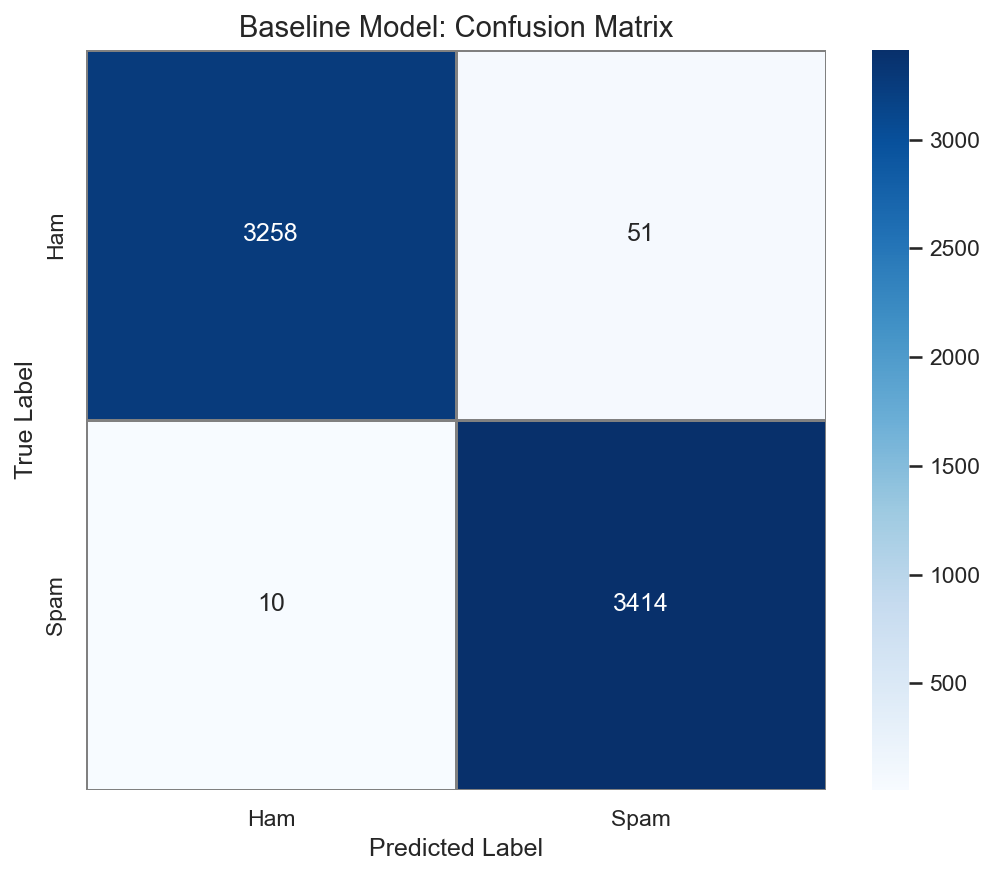

True Negatives (Ham correctly classified):  3258
False Positives (Ham misclassified as Spam): 51
False Negatives (Spam misclassified as Ham): 10
True Positives (Spam correctly classified):  3414


In [8]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'],
            ax=ax, linewidths=0.5, linecolor='gray')
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Baseline Model: Confusion Matrix', fontsize=14)

plt.tight_layout()
plt.savefig('../../evaluation/baseline_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Print breakdown
tn, fp, fn, tp = cm.ravel()
print(f'True Negatives (Ham correctly classified):  {tn}')
print(f'False Positives (Ham misclassified as Spam): {fp}')
print(f'False Negatives (Spam misclassified as Ham): {fn}')
print(f'True Positives (Spam correctly classified):  {tp}')

## 8. ROC curve

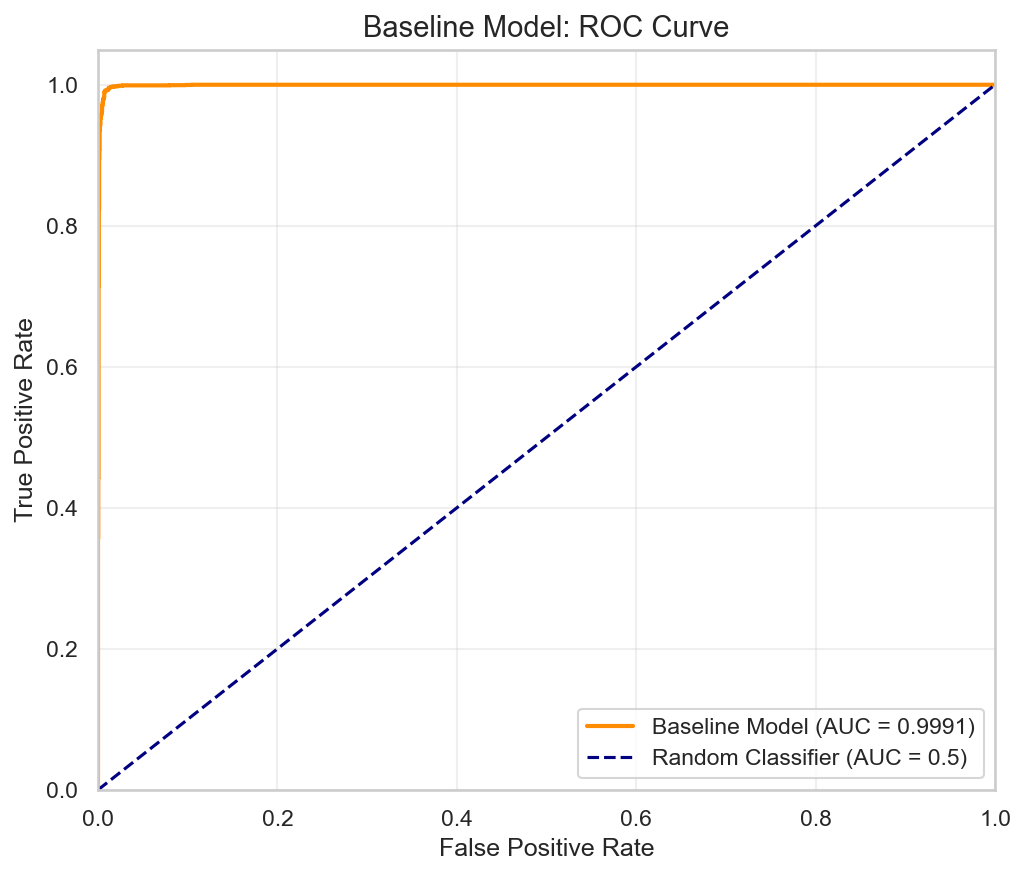

In [9]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'Baseline Model (AUC = {auc:.4f})')
ax.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Classifier (AUC = 0.5)')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Baseline Model: ROC Curve', fontsize=14)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../../evaluation/baseline_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Feature importance

The Logistic Regression coefficients map straight onto "this token pushes a prediction toward spam (positive coefficient) or ham (negative coefficient)". That is one of the things the baseline can do that DistilBERT cannot do without extra tooling: I can read off exactly which features are doing the work, and a marker can sanity-check the model from the chart alone.

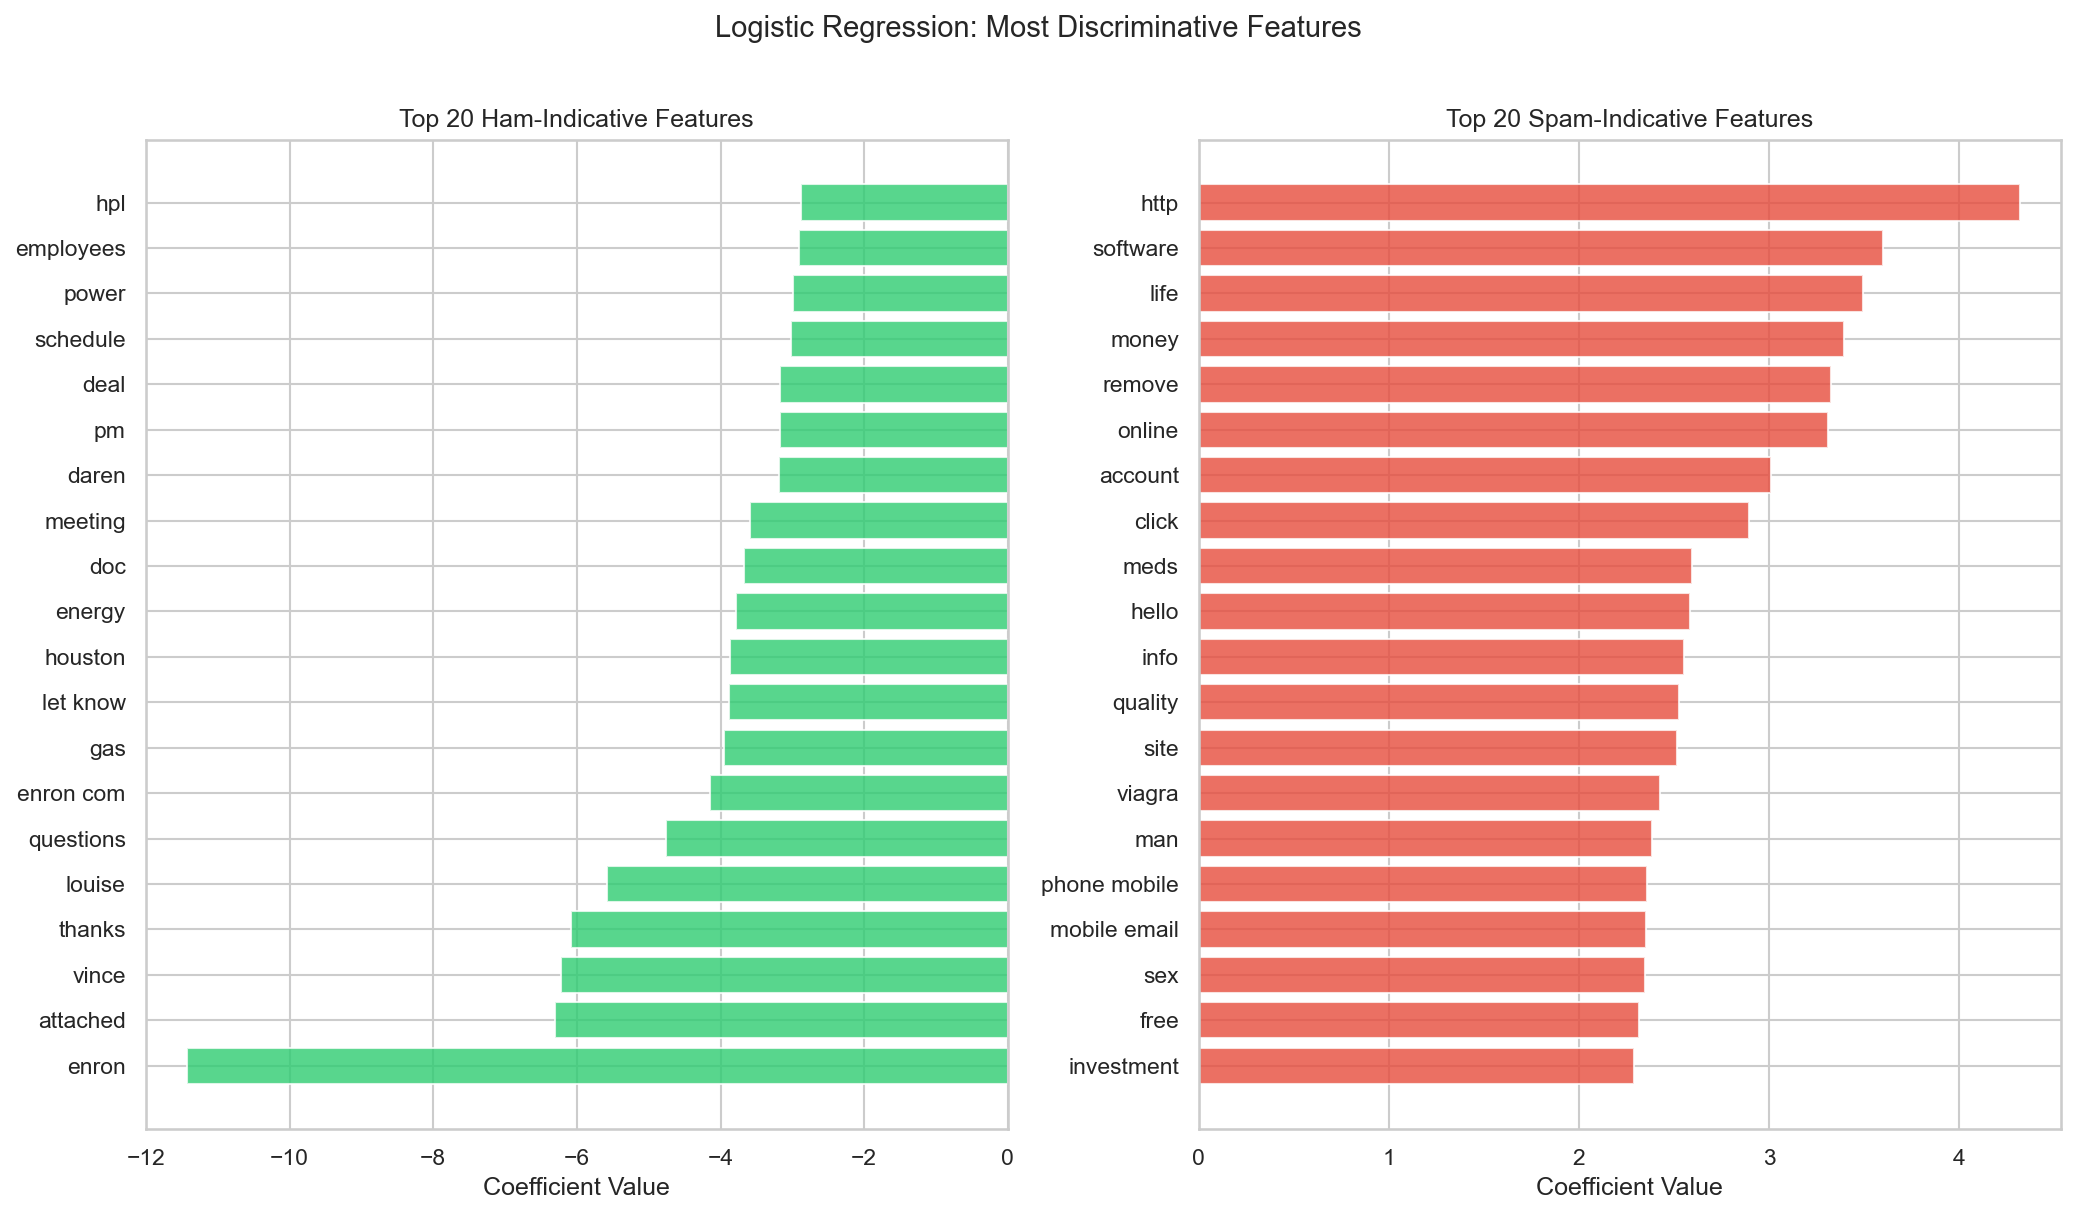

In [10]:
feature_names = tfidf.get_feature_names_out()
coefficients = lr_model.coef_[0]

# Top 20 spam-indicative features (highest positive coefficients)
spam_indices = np.argsort(coefficients)[-20:]
# Top 20 ham-indicative features (most negative coefficients)
ham_indices = np.argsort(coefficients)[:20]

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# Ham features
axes[0].barh(range(20), coefficients[ham_indices], color='#2ecc71', alpha=0.8)
axes[0].set_yticks(range(20))
axes[0].set_yticklabels(feature_names[ham_indices])
axes[0].set_title('Top 20 Ham-Indicative Features', fontsize=12)
axes[0].set_xlabel('Coefficient Value')

# Spam features
axes[1].barh(range(20), coefficients[spam_indices], color='#e74c3c', alpha=0.8)
axes[1].set_yticks(range(20))
axes[1].set_yticklabels(feature_names[spam_indices])
axes[1].set_title('Top 20 Spam-Indicative Features', fontsize=12)
axes[1].set_xlabel('Coefficient Value')

plt.suptitle('Logistic Regression: Most Discriminative Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../../evaluation/baseline_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

## 10. Save model and vectoriser

Both pieces have to be saved together. The vectoriser holds the vocabulary and the IDF weights learned from the training data; if I rebuilt it on new data at inference time, I'd get a different vocabulary and totally different feature columns, and the saved model's coefficients would point at the wrong features. Save them as a pair, load them as a pair.

In [ ]:
joblib.dump(lr_model, '../models/baseline_logistic_regression_model.pkl')
joblib.dump(tfidf, '../models/baseline_tfidf_vectorizer.pkl')

print('Saved:')
print(f'  Model:      ml/models/baseline_logistic_regression_model.pkl')
print(f'  Vectoriser: ml/models/baseline_tfidf_vectorizer.pkl')

## 11. Export results

Dump every metric into a CSV so the comparison against DistilBERT in notebook 03 and the adversarial evaluation in Phase 6 can both read from a single source of truth, with no copy/paste of numbers.

In [12]:
results = pd.DataFrame([{
    'Model': 'TF-IDF + Logistic Regression',
    'Accuracy': round(acc, 4),
    'Precision': round(prec, 4),
    'Recall': round(rec, 4),
    'F1': round(f1, 4),
    'ROC-AUC': round(auc, 4),
    'Train Size': len(X_train),
    'Test Size': len(X_test),
    'Features': X_train_tfidf.shape[1],
    'True Negatives': int(tn),
    'False Positives': int(fp),
    'False Negatives': int(fn),
    'True Positives': int(tp)
}])

results.to_csv('../../evaluation/baseline_results.csv', index=False)
print('Results saved to evaluation/baseline_results.csv')
print()
print(results.T.to_string(header=False))

Results saved to evaluation/baseline_results.csv

Model            TF-IDF + Logistic Regression
Accuracy                               0.9909
Precision                              0.9853
Recall                                 0.9971
F1                                     0.9911
ROC-AUC                                0.9991
Train Size                              26929
Test Size                                6733
Features                                10000
True Negatives                           3258
False Positives                            51
False Negatives                            10
True Positives                           3414


## Summary

The TF-IDF + Logistic Regression baseline does well on clean data, which was the easy part. The real research question is what happens when an adversary actively tries to evade it. The baseline gets compared against a fine-tuned DistilBERT model under three attack families:

1. Character-level perturbation: typos, unicode swaps, internal-character edits.
2. Synonym substitution: replace content words with WordNet synonyms.
3. Good-word injection (text dilution): pad spam with benign professional vocabulary.

My working hypothesis is that the TF-IDF baseline, since it relies on exact token matches, will lose more ground to all three attacks than the transformer model, which has at least some chance of generalising via contextual embeddings. The point of Phase 6 is to find out whether that hypothesis survives contact with the data.